[*********************100%***********************]  5 of 5 completed


=== Portfolio Performance ===
Total Return:          42.35%
Annualized Return:     37.372410%
Annualized Volatility: 18.78%
Sharpe Ratio:          1.99
Date
2026-06-01    1.496422
2026-06-02    1.482829
2026-06-03    1.454864
2026-06-04    1.468832
2026-06-05    1.423475
dtype: float64


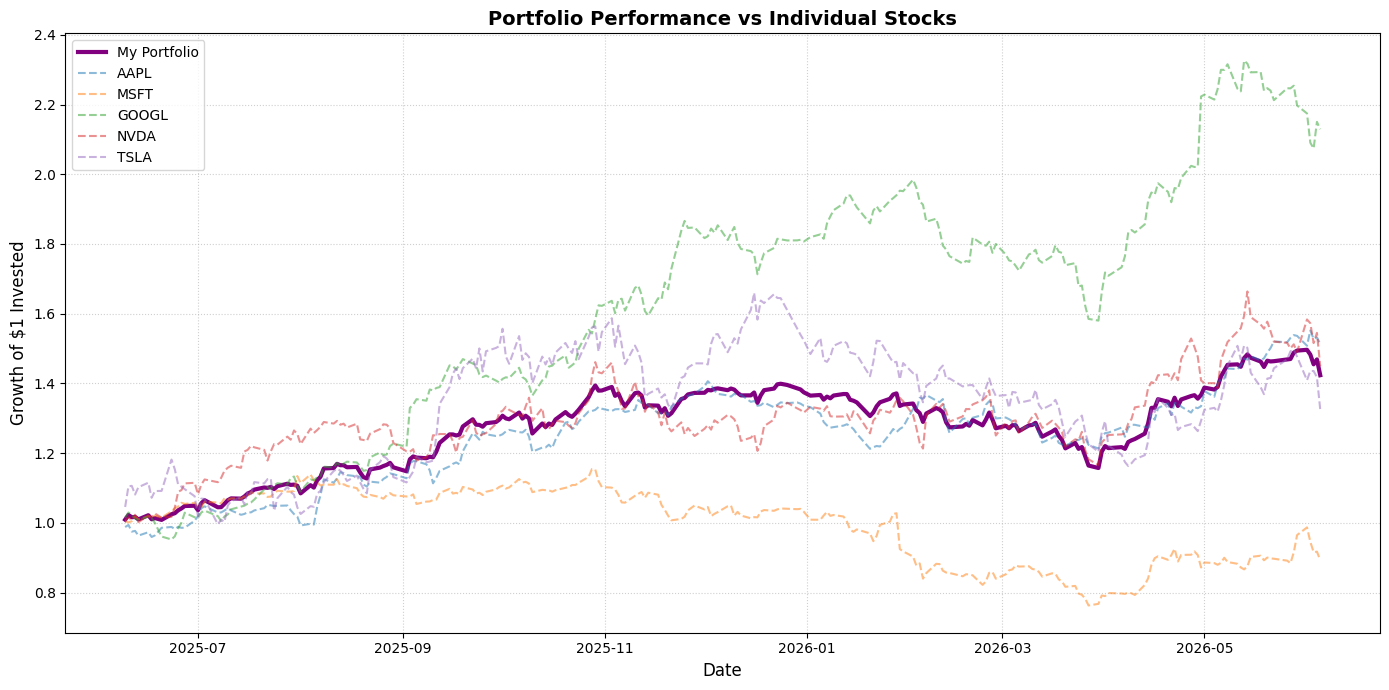

In [10]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Define portfolio using a dictionary to lock weights to explicit tickers
ticker_weights = {
    'AAPL': 0.25, 
    'MSFT': 0.25, 
    'GOOGL': 0.20, 
    'NVDA': 0.15, 
    'TSLA': 0.15
}

# Convert weights to a labeled Pandas Series
weights = pd.Series(ticker_weights)
tickers = list(ticker_weights.keys())

# Download adjusted close prices
data = yf.download(tickers, period="1y", interval="1d")['Close']

# Calculate daily returns
returns = data.pct_change().dropna()

# Portfolio daily returns 
# SAFE: Pandas auto-aligns 'returns' columns with 'weights' index matching labels!
portfolio_returns = returns.dot(weights)

# Cumulative performance
cumulative = (1 + portfolio_returns).cumprod()

# === Key Metrics ===
print("=== Portfolio Performance ===")
# SAFE: Using .iloc[-1] to ensure positional lookup on DatetimeIndex
print(f"Total Return:          {(cumulative.iloc[-1] - 1)*100:.2f}%")
print(f"Annualized Return:     {portfolio_returns.mean() * 252 * 100:.6f}%")
print(f"Annualized Volatility: {portfolio_returns.std() * (252**0.5) * 100:.2f}%")
print(f"Sharpe Ratio:          {(portfolio_returns.mean() / portfolio_returns.std()) * (252**0.5):.2f}")

# Plotting configuration
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cumulative.index, cumulative, label='My Portfolio', linewidth=3, color='purple')

for ticker in tickers:
    ax.plot(returns.index, (1 + returns[ticker]).cumprod(), label=ticker, alpha=0.5, linestyle='--')

ax.set_title('Portfolio Performance vs Individual Stocks', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Growth of $1 Invested', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('portfolio_backtest.png', dpi=300)

print(cumulative.tail())

### Options Theory Notes (Implied Volatility)

- **What is Implied Volatility (IV)?**  
  Implied Volatility is the market’s expectation of how much a stock’s price is likely to move in the future. It is derived from current option prices and reflects the collective sentiment of traders. It is one of the key inputs (along with stock price, strike price, time to expiration, interest rates, and dividends) that determines an option’s price.

- **Why is High IV Good for Selling Covered Calls?**  
  High Implied Volatility causes option premiums to be more expensive. As a covered call seller, you **collect more premium** when IV is high. This gives you:
  - A larger **income buffer** (more downside protection)
  - Higher potential profit from the premium
  - Better risk-reward when the stock is range-bound or mildly bullish

- **Key Takeaway:**  
  Covered call sellers generally prefer **high IV environments** because they can sell options at richer prices. However, high IV often occurs before big events (earnings, news), which can also mean higher risk of sharp moves.